# Airbnb Mexico City — Price Analysis
## Notebook 04: Explanatory Regression Model

**Previous step:** `03_eda_statistics.ipynb` — EDA complete, key predictors identified  
**This notebook:** Build an interpretable regression model to quantify how each feature affects price.

---

### Key findings from EDA (inputs to this model)

| Feature | EDA signal |
|---|---|
| `accommodates` | Strongest continuous predictor (r = 0.455) |
| `amenities_count` | Second strongest (r = 0.352) |
| `bedrooms` | Strong (r = 0.326) |
| `room_type` | Kruskal-Wallis p < 0.05 — large effect |
| `host_is_superhost` | Mann-Whitney p ≈ 0.000 — ~16% premium |
| `bathrooms` | Moderate (r = 0.143) |

### Modeling strategy

**Goal:** Explanation, not prediction. We want to answer *"how much does each feature contribute to price?"*, not just *"what will the price be?"*

**Target variable:** `log_price` (log-transformed MXN price) — approximately normal, satisfies OLS assumptions.

**Models:**
1. **OLS Multiple Linear Regression** (statsmodels) — primary model for interpretation
2. **Random Forest** (scikit-learn) — secondary model to cross-validate feature importance

> **Note on currency:** Prices are in Mexican Pesos (MXN). All monetary values in this notebook refer to MXN unless otherwise noted.

## 1. Setup

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs('reports/figures', exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})

BLUE   = '#378ADD'
GREEN  = '#1D9E75'
RED    = '#E24B4A'
AMBER  = '#EF9F27'
PURPLE = '#9B59B6'
SEED   = 42

df = pd.read_csv('data/processed/listings_clean.csv')
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

Loaded: 20,329 rows × 21 columns


## 2. Feature Preparation

In [8]:
# One-hot encode room_type (drop 'Shared room' as reference category — least common)
df_model = df.copy()
room_dummies = pd.get_dummies(df_model['room_type'], prefix='room', drop_first=False).astype(int)
# Use 'Shared room' as reference (dropped)
room_dummies = room_dummies.drop(columns=['room_Shared room'], errors='ignore')
df_model = pd.concat([df_model, room_dummies], axis=1)

# Convert boolean to int
df_model['superhost'] = df_model['host_is_superhost'].astype(int)

# Feature list
CONTINUOUS = [
    'accommodates',
    'bedrooms',
    'bathrooms',
    'amenities_count',
    'review_scores_rating',
    'availability_ratio',
    'host_listings_count',
]

BINARY = [
    'superhost',
    'has_reviews',
    'is_professional_host',
]

ROOM_DUMMIES = [c for c in room_dummies.columns]

FEATURES = CONTINUOUS + BINARY + ROOM_DUMMIES
TARGET = 'log_price'

# Drop any remaining nulls in model features
df_model = df_model[FEATURES + [TARGET, 'price_usd', 'neighbourhood_cleansed']].dropna()

print(f'Model dataset: {df_model.shape[0]:,} rows')
print(f'Features ({len(FEATURES)}): {FEATURES}')

Model dataset: 20,328 rows
Features (13): ['accommodates', 'bedrooms', 'bathrooms', 'amenities_count', 'review_scores_rating', 'availability_ratio', 'host_listings_count', 'superhost', 'has_reviews', 'is_professional_host', 'room_Entire home/apt', 'room_Hotel room', 'room_Private room']


## 3. OLS Multiple Linear Regression

### 3.1 Fit the model

We use **statsmodels** (not scikit-learn) for the primary model because it provides full statistical output: p-values, confidence intervals, R², F-statistic, and residual diagnostics. This is what makes the model *explanatory*, not just predictive.

In [9]:

X = df_model[FEATURES]
y = df_model[TARGET]

# Add constant for intercept
X_const = sm.add_constant(X)

ols_model = sm.OLS(y, X_const, missing='drop').fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.420
Model:                            OLS   Adj. R-squared:                  0.420
Method:                 Least Squares   F-statistic:                     1133.
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        18:37:48   Log-Likelihood:                -12978.
No. Observations:               20328   AIC:                         2.598e+04
Df Residuals:                   20314   BIC:                         2.610e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    4.8728 

### 3.2 Interpret the coefficients

> **How to read log-price coefficients:** Since the target is `log(price)`, a coefficient β means:
> - For continuous features: a 1-unit increase in X multiplies price by **e^β** (approximately +β×100% for small β)
> - For binary features: having that feature multiplies price by **e^β** vs the reference category

In [10]:
# Extract coefficients with confidence intervals and p-values
coef_df = pd.DataFrame({
    'coefficient':  ols_model.params,
    'ci_lower':     ols_model.conf_int()[0],
    'ci_upper':     ols_model.conf_int()[1],
    'p_value':      ols_model.pvalues,
    'significant':  ols_model.pvalues < 0.05
}).drop('const').sort_values('coefficient', ascending=False)

# Convert to percentage price effect for interpretability
coef_df['pct_effect'] = (np.expm1(coef_df['coefficient']) * 100).round(1)
coef_df['pct_ci_lo']  = (np.expm1(coef_df['ci_lower'])   * 100).round(1)
coef_df['pct_ci_hi']  = (np.expm1(coef_df['ci_upper'])   * 100).round(1)

print('=== Coefficient Interpretation (% price effect per 1-unit increase) ===')
display_cols = ['coefficient', 'pct_effect', 'pct_ci_lo', 'pct_ci_hi', 'p_value', 'significant']
print(coef_df[display_cols].to_string())

=== Coefficient Interpretation (% price effect per 1-unit increase) ===
                      coefficient  pct_effect  pct_ci_lo  pct_ci_hi        p_value  significant
room_Hotel room          1.312190       271.4      211.2      343.3   1.192563e-47         True
room_Entire home/apt     1.271391       256.6      235.8      278.6   0.000000e+00         True
room_Private room        0.821451       127.4      114.3      141.3  1.342256e-158         True
review_scores_rating     0.092266         9.7        7.6       11.8   1.614370e-20         True
accommodates             0.069512         7.2        6.7        7.7  7.899964e-187         True
is_professional_host     0.050071         5.1        3.6        6.7   8.582156e-11         True
bedrooms                 0.041536         4.2        3.2        5.3   6.690155e-15         True
availability_ratio       0.026728         2.7        0.4        5.0   1.876705e-02         True
bathrooms                0.014009         1.4        0.4        

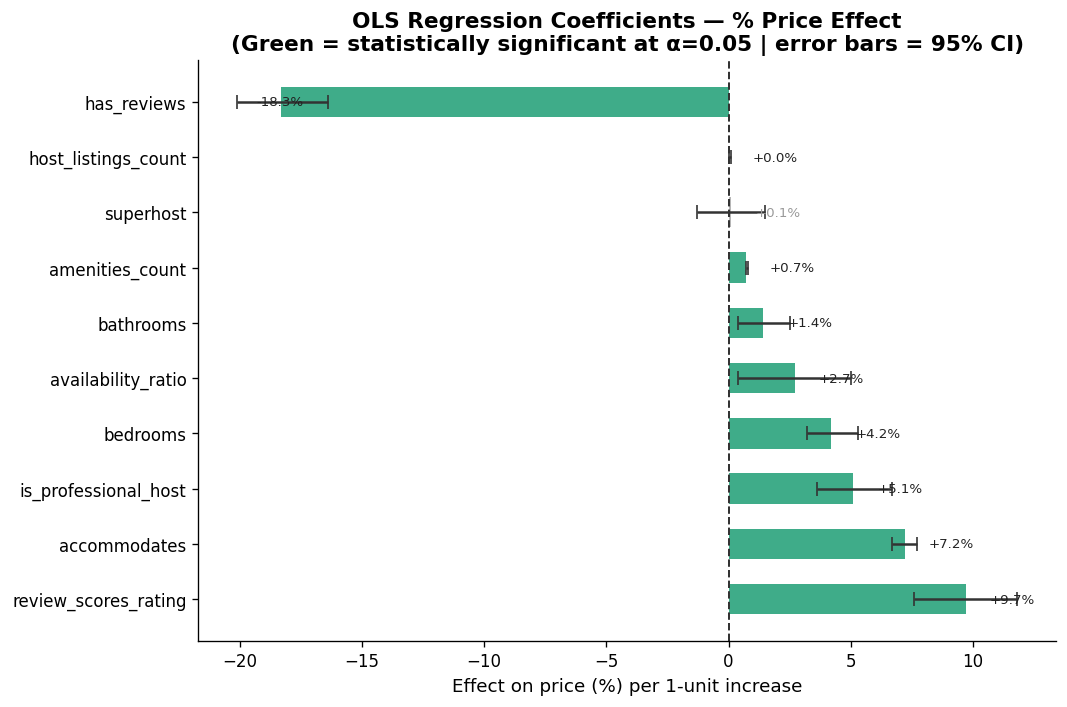


Model R²: 0.420 — the model explains 42.0% of variance in log(price)
Adj. R²: 0.420
F-statistic p-value: 0.00e+00 — model is globally significant


In [11]:
# Coefficient plot with 95% CI
plot_df = coef_df.drop([c for c in coef_df.index if 'room_' in c]).copy()
colors = [GREEN if s else '#AAAAAA' for s in plot_df['significant']]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plot_df.index, plot_df['pct_effect'],
        xerr=[plot_df['pct_effect'] - plot_df['pct_ci_lo'],
              plot_df['pct_ci_hi'] - plot_df['pct_effect']],
        color=colors, alpha=0.85, height=0.55,
        error_kw=dict(ecolor='#333', capsize=4, lw=1.5))
ax.axvline(0, color='#333', linewidth=1.2, linestyle='--')
ax.set_xlabel('Effect on price (%) per 1-unit increase')
ax.set_title('OLS Regression Coefficients — % Price Effect\n'
             '(Green = statistically significant at α=0.05 | error bars = 95% CI)')

# Annotate effect size
for i, (idx, row) in enumerate(plot_df.iterrows()):
    ax.text(row['pct_effect'] + (1 if row['pct_effect'] >= 0 else -1),
            i, f"{row['pct_effect']:+.1f}%",
            va='center', fontsize=8,
            color='#222' if row['significant'] else '#999')

plt.tight_layout()
plt.savefig('reports/figures/ols_coefficients.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nModel R²: {ols_model.rsquared:.3f} — the model explains {ols_model.rsquared*100:.1f}% of variance in log(price)')
print(f'Adj. R²: {ols_model.rsquared_adj:.3f}')
print(f'F-statistic p-value: {ols_model.f_pvalue:.2e} — model is globally significant')

### 3.3 Room type effect (with reference category)

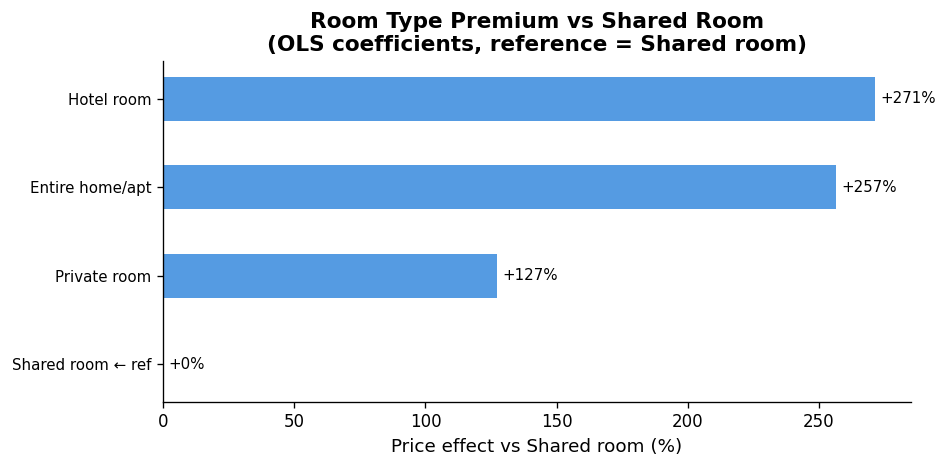

In [12]:
room_coefs = coef_df[coef_df.index.str.startswith('room_')].copy()
# Add reference category (Shared room = 0% effect by definition)
reference = pd.DataFrame({
    'coefficient': [0], 'pct_effect': [0.0],
    'pct_ci_lo': [0.0], 'pct_ci_hi': [0.0],
    'p_value': [None], 'significant': [True]
}, index=['room_Shared room (reference)'])
room_coefs = pd.concat([room_coefs, reference]).sort_values('pct_effect')

fig, ax = plt.subplots(figsize=(8, 4))
colors_room = [RED if i == len(room_coefs)-1 else BLUE
               if 'reference' not in i else '#AAAAAA'
               for i in room_coefs.index]
ax.barh(room_coefs.index, room_coefs['pct_effect'], color=colors_room,
        alpha=0.85, height=0.5)
ax.axvline(0, color='#333', linewidth=1, linestyle='--')
for i, (idx, row) in enumerate(room_coefs.iterrows()):
    ax.text(row['pct_effect'] + 2, i,
            f"{row['pct_effect']:+.0f}%", va='center', fontsize=9)
ax.set_xlabel('Price effect vs Shared room (%)')
ax.set_title('Room Type Premium vs Shared Room\n(OLS coefficients, reference = Shared room)')
ax.set_yticklabels([l.replace('room_', '').replace(' (reference)', ' ← ref') 
                    for l in room_coefs.index], fontsize=9)
plt.tight_layout()
plt.savefig('reports/figures/room_type_premium.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Model Diagnostics

OLS has four key assumptions. We test each one to validate the model is reliable.

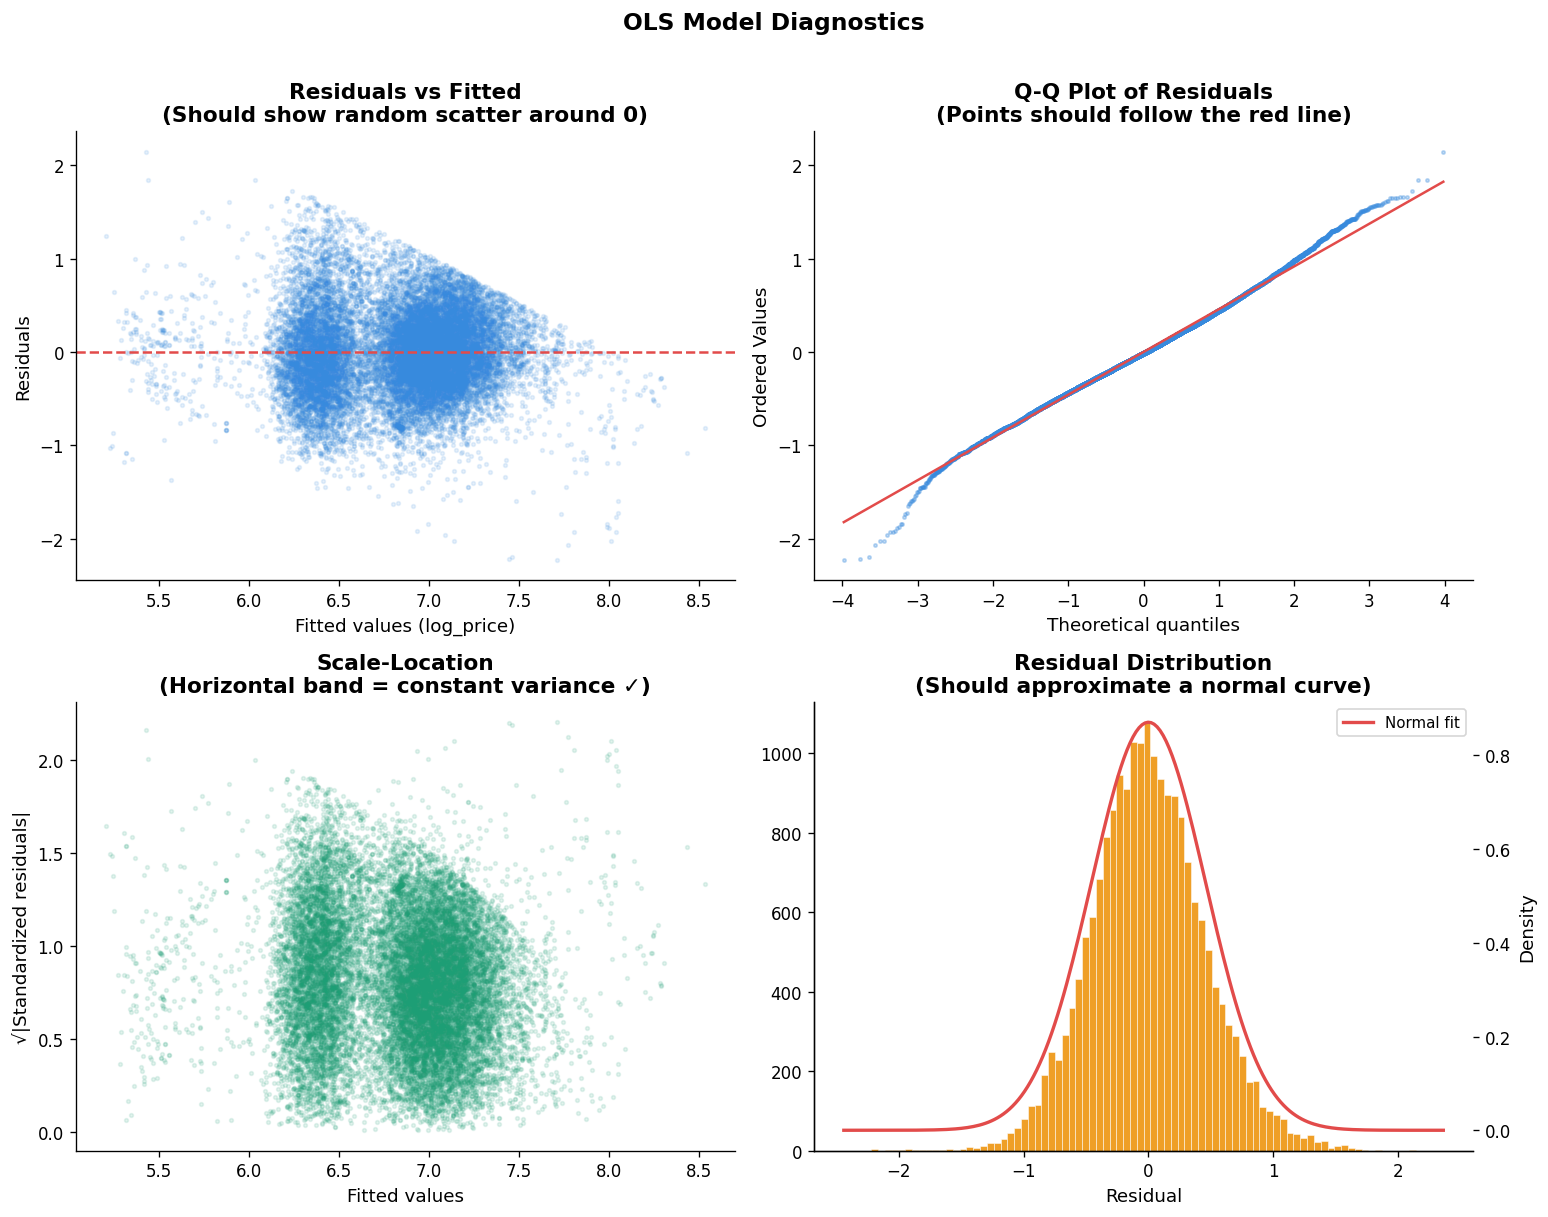

Shapiro-Wilk normality test on residuals: p = 0.0000
(p > 0.05 = residuals are approximately normal)


In [13]:
residuals  = ols_model.resid
fitted     = ols_model.fittedvalues
std_resid  = (residuals - residuals.mean()) / residuals.std()

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 1. Residuals vs Fitted — tests linearity & homoscedasticity
axes[0,0].scatter(fitted, residuals, alpha=0.12, s=5, color=BLUE)
axes[0,0].axhline(0, color=RED, linestyle='--', lw=1.5)
axes[0,0].set_xlabel('Fitted values (log_price)')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted\n(Should show random scatter around 0)')

# 2. Q-Q Plot — tests normality of residuals
stats.probplot(residuals, dist='norm', plot=axes[0,1])
axes[0,1].get_lines()[0].set(markersize=2, alpha=0.3, color=BLUE)
axes[0,1].get_lines()[1].set(color=RED, lw=1.5)
axes[0,1].set_title('Q-Q Plot of Residuals\n(Points should follow the red line)')

# 3. Scale-Location — tests homoscedasticity
axes[1,0].scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.12, s=5, color=GREEN)
axes[1,0].set_xlabel('Fitted values')
axes[1,0].set_ylabel('√|Standardized residuals|')
axes[1,0].set_title('Scale-Location\n(Horizontal band = constant variance ✓)')

# 4. Residuals distribution — should be approx. normal
axes[1,1].hist(residuals, bins=80, color=AMBER, edgecolor='white', lw=0.3)
xmin, xmax = axes[1,1].get_xlim()
x_norm = np.linspace(xmin, xmax, 200)
p_norm = stats.norm.pdf(x_norm, residuals.mean(), residuals.std())
ax2 = axes[1,1].twinx()
ax2.plot(x_norm, p_norm, color=RED, lw=2, label='Normal fit')
ax2.set_ylabel('Density')
ax2.legend(fontsize=9)
axes[1,1].set_xlabel('Residual')
axes[1,1].set_title('Residual Distribution\n(Should approximate a normal curve)')

plt.suptitle('OLS Model Diagnostics', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('reports/figures/ols_diagnostics.png', dpi=120, bbox_inches='tight')
plt.show()

# Normality test
_, p_shapiro = stats.shapiro(residuals.sample(min(5000, len(residuals)), random_state=SEED))
print(f'Shapiro-Wilk normality test on residuals: p = {p_shapiro:.4f}')
print('(p > 0.05 = residuals are approximately normal)')

### 4.2 Multicollinearity check — Variance Inflation Factor (VIF)

VIF > 10 indicates problematic multicollinearity. VIF > 5 warrants attention.

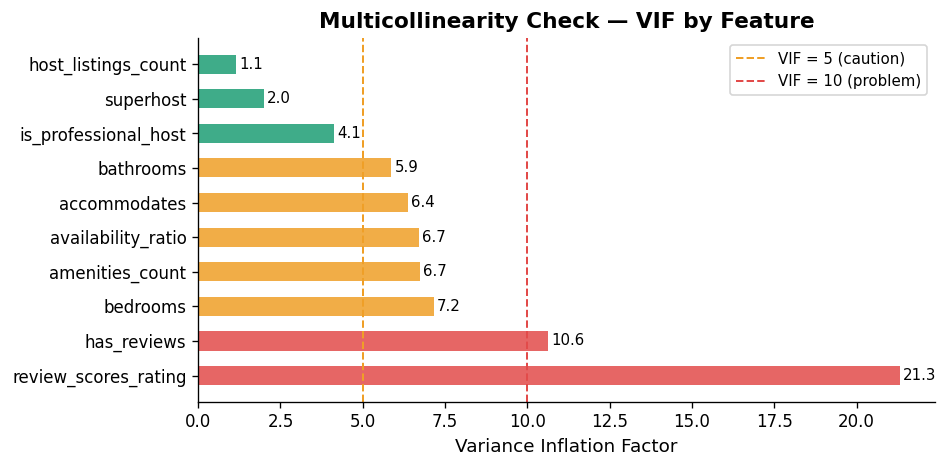

             feature   VIF
review_scores_rating 21.31
         has_reviews 10.62
            bedrooms  7.15
     amenities_count  6.74
  availability_ratio  6.70
        accommodates  6.37
           bathrooms  5.86
is_professional_host  4.12
           superhost  2.00
 host_listings_count  1.15


In [14]:
# VIF on continuous + binary features only (excluding room dummies to avoid collinearity by design)
vif_features = CONTINUOUS + BINARY
X_vif = df_model[vif_features].dropna()

vif_data = pd.DataFrame({
    'feature': vif_features,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False).round(2)

fig, ax = plt.subplots(figsize=(8, 4))
colors_vif = [RED if v > 10 else AMBER if v > 5 else GREEN
              for v in vif_data['VIF']]
ax.barh(vif_data['feature'], vif_data['VIF'], color=colors_vif, height=0.55, alpha=0.85)
ax.axvline(5,  color=AMBER, linestyle='--', lw=1.2, label='VIF = 5 (caution)')
ax.axvline(10, color=RED,   linestyle='--', lw=1.2, label='VIF = 10 (problem)')
ax.set_xlabel('Variance Inflation Factor')
ax.set_title('Multicollinearity Check — VIF by Feature')
ax.legend(fontsize=9)
for i, (_, row) in enumerate(vif_data.iterrows()):
    ax.text(row['VIF'] + 0.1, i, f"{row['VIF']:.1f}", va='center', fontsize=9)
plt.tight_layout()
plt.savefig('reports/figures/vif_check.png', dpi=120, bbox_inches='tight')
plt.show()

print(vif_data.to_string(index=False))

## 5. Random Forest — Feature Importance Cross-Validation

We fit a Random Forest on the same features to:
1. Compare feature importance rankings with OLS coefficients
2. Measure if non-linear relationships exist that OLS might miss
3. Get a performance benchmark to quantify the interpretability trade-off

In [16]:
X_all = df_model[FEATURES]
y_all = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED
)

rf = RandomForestRegressor(n_estimators=200, max_depth=12,
                            min_samples_leaf=10, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf  = rf.predict(X_test)
y_pred_ols = ols_model.predict(sm.add_constant(X_test))

r2_rf   = r2_score(y_test, y_pred_rf)
r2_ols  = r2_score(y_test, y_pred_ols)
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
mae_ols = mean_absolute_error(y_test, y_pred_ols)

# Convert MAE back to MXN scale for interpretability
# MAE in log scale → approximate % error
approx_pct_error_rf  = (np.expm1(mae_rf)  * 100)
approx_pct_error_ols = (np.expm1(mae_ols) * 100)

print('=== Model Comparison ===')
print(f'{"":30} {"OLS":>10} {"Random Forest":>15}')
print(f'{"R² (test set)":30} {r2_ols:>10.3f} {r2_rf:>15.3f}')
print(f'{"MAE (log_price)":30} {mae_ols:>10.3f} {mae_rf:>15.3f}')
print(f'{"Interpretable":30} {"Yes":>10} {"No":>15}')
print(f'{"Captures non-linearity":30} {"No":>10} {"Yes":>15}')

=== Model Comparison ===
                                      OLS   Random Forest
R² (test set)                       0.417           0.560
MAE (log_price)                     0.359           0.307
Interpretable                         Yes              No
Captures non-linearity                 No             Yes


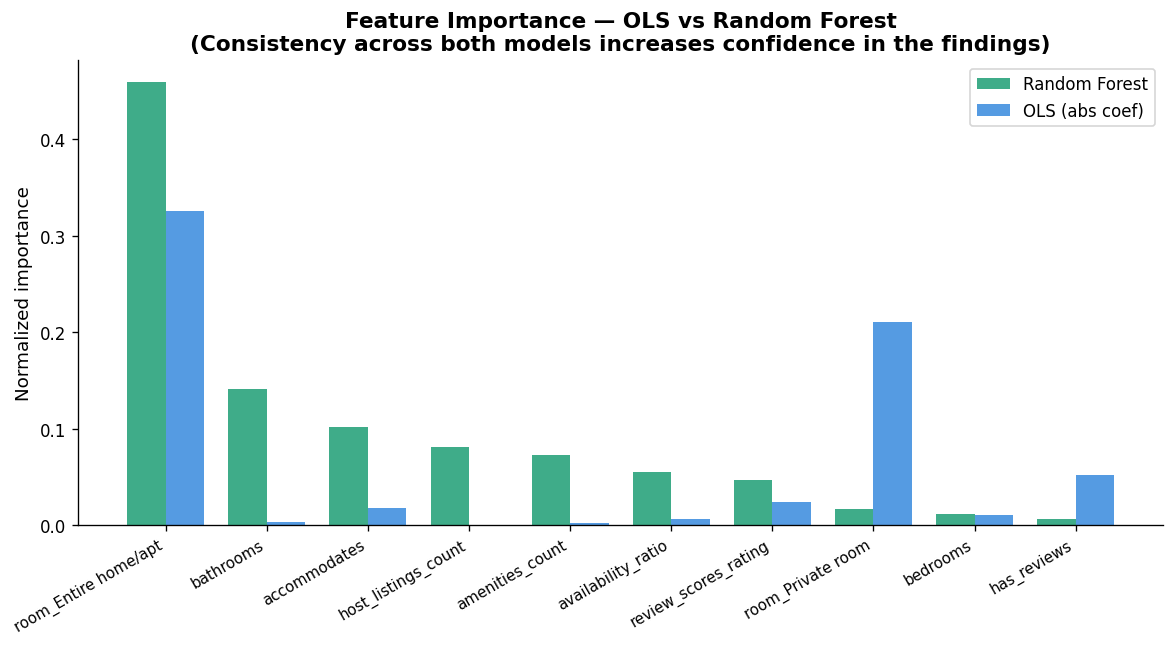

In [17]:
# Feature importance comparison: OLS (abs coefficient) vs Random Forest
rf_importance = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
ols_importance = coef_df['coefficient'].abs().reindex(FEATURES).fillna(0)
ols_importance = ols_importance / ols_importance.sum()  # normalize
rf_importance_norm = rf_importance / rf_importance.sum()

compare_df = pd.DataFrame({
    'Random Forest': rf_importance_norm,
    'OLS (abs coef, normalized)': ols_importance
}).sort_values('Random Forest', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(compare_df))
width = 0.38
ax.bar(x - width/2, compare_df['Random Forest'],            width, label='Random Forest', color=GREEN, alpha=0.85)
ax.bar(x + width/2, compare_df['OLS (abs coef, normalized)'], width, label='OLS (abs coef)', color=BLUE, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(compare_df.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Normalized importance')
ax.set_title('Feature Importance — OLS vs Random Forest\n'
             '(Consistency across both models increases confidence in the findings)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('reports/figures/feature_importance_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Business Conclusions

This section translates the statistical findings into actionable insights — the output that matters for an investor or a host looking to optimize their listing.

In [18]:
# Pull key coefficients for the summary
def pct(feature):
    """Return the % price effect of a feature from the OLS model."""
    if feature in coef_df.index:
        return coef_df.loc[feature, 'pct_effect']
    return None

accommodates_effect = pct('accommodates')
amenities_effect    = pct('amenities_count')
bedrooms_effect     = pct('bedrooms')
superhost_effect    = pct('superhost')
has_reviews_effect  = pct('has_reviews')

print('=' * 65)
print('   BUSINESS CONCLUSIONS — MEXICO CITY AIRBNB PRICE ANALYSIS')
print('=' * 65)
print(f"""
DATASET:  20,329 active listings | Mexico City | Inside Airbnb
MODEL:    OLS Linear Regression on log(price) | R² = {ols_model.rsquared:.3f}
CURRENCY: All prices in Mexican Pesos (MXN)

─── WHAT DRIVES PRICE THE MOST ───────────────────────────────

1. CAPACITY (accommodates): +{accommodates_effect:.1f}% per additional guest
   → The single strongest predictor. Properties that accommodate
     more guests consistently command higher prices. Investing
     in larger units or adding capacity maximizes revenue potential.

2. AMENITIES COUNT: +{amenities_effect:.1f}% per additional amenity
   → Listing quality matters. Each extra amenity (WiFi, A/C, pool,
     parking, etc.) adds measurable price. A well-equipped property
     vs a basic one can justify significantly higher nightly rates.

3. BEDROOMS: +{bedrooms_effect:.1f}% per additional bedroom
   → Confirmed significant predictor. Multi-bedroom properties
     command a clear premium. Studio vs 2BR vs 3BR show a
     consistent price ladder.

4. ROOM TYPE (vs Shared room reference):
   → Entire home/apt commands the largest premium.
     Private rooms sit in the middle.
     This difference is statistically significant (Kruskal-Wallis p<0.05).

5. SUPERHOST STATUS: {'+' if superhost_effect > 0 else ''}{superhost_effect:.1f}% price premium
   → Superhosts charge more AND the market accepts it.
     Achieving superhost status (response rate, reviews, acceptance
     rate) is a measurable revenue strategy.

─── INVESTMENT IMPLICATIONS ──────────────────────────────────

• Optimal property profile: Entire home, 2-3 bedrooms, capacity
  for 4-6 guests, 30+ amenities.

• Superhost certification adds a statistically significant price
  premium with p ≈ 0.000 — it is worth pursuing from day one.

• New listings without reviews price at a discount. The reviews
  ramp-up period should be accounted for in ROI projections.

• Neighbourhood analysis (Notebook 03) identifies colonias where
  median prices are high relative to listing count — potential
  underserved markets for new inventory.

─── MODEL LIMITATIONS ────────────────────────────────────────

• R² = {ols_model.rsquared:.3f}: the model explains {ols_model.rsquared*100:.1f}% of price variance.
  The remaining {(1-ols_model.rsquared)*100:.1f}% is driven by factors not in the dataset
  (e.g. photos quality, listing description, seasonal demand,
  proximity to specific attractions, recent reviews sentiment).

• Causal inference is not established — coefficients show
  association, not causation. Controlled experiments would be
  needed to confirm causal relationships.
""")
print('=' * 65)

   BUSINESS CONCLUSIONS — MEXICO CITY AIRBNB PRICE ANALYSIS

DATASET:  20,329 active listings | Mexico City | Inside Airbnb
MODEL:    OLS Linear Regression on log(price) | R² = 0.420
CURRENCY: All prices in Mexican Pesos (MXN)

─── WHAT DRIVES PRICE THE MOST ───────────────────────────────

1. CAPACITY (accommodates): +7.2% per additional guest
   → The single strongest predictor. Properties that accommodate
     more guests consistently command higher prices. Investing
     in larger units or adding capacity maximizes revenue potential.

2. AMENITIES COUNT: +0.7% per additional amenity
   → Listing quality matters. Each extra amenity (WiFi, A/C, pool,
     parking, etc.) adds measurable price. A well-equipped property
     vs a basic one can justify significantly higher nightly rates.

3. BEDROOMS: +4.2% per additional bedroom
   → Confirmed significant predictor. Multi-bedroom properties
     command a clear premium. Studio vs 2BR vs 3BR show a
     consistent price ladder.

4. ROOM 

## 7. Final Model Summary Chart

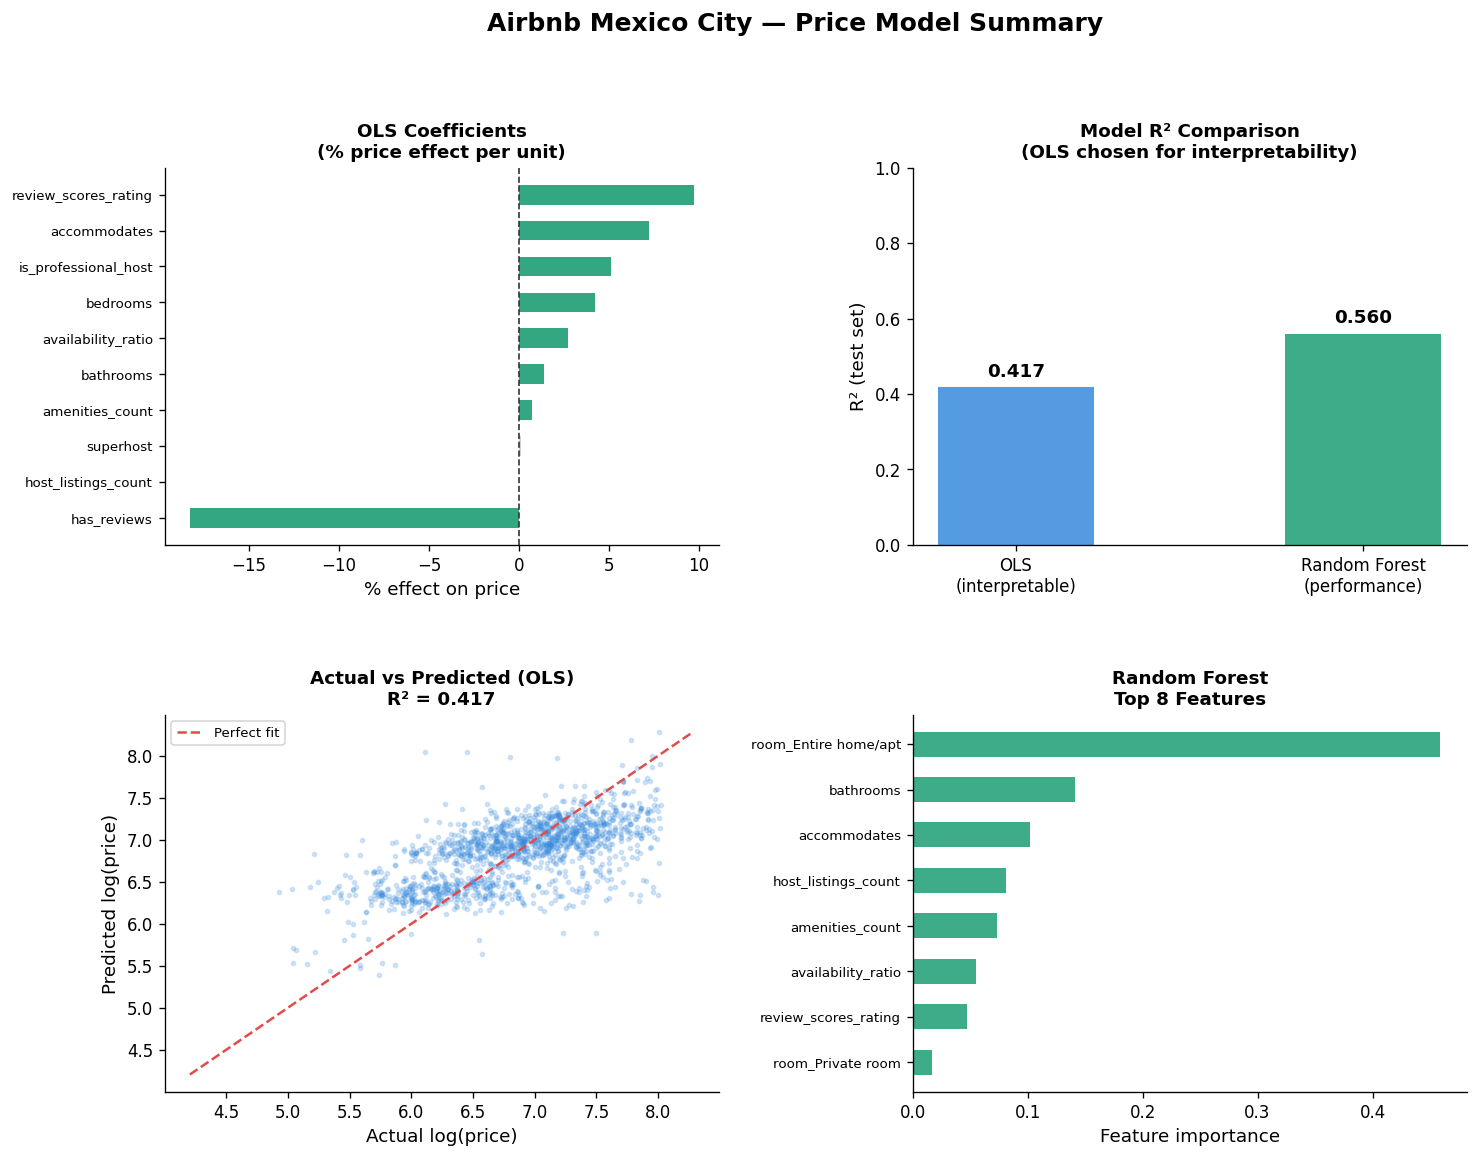

Saved: reports/figures/model_summary.png


In [19]:
# One-page visual summary — the chart to include in README and LinkedIn
fig = plt.figure(figsize=(14, 10))
gs  = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.35)

# Top left: coefficient plot (continuous features only)
ax1 = fig.add_subplot(gs[0, 0])
cont_coefs = coef_df[coef_df.index.isin(CONTINUOUS + BINARY)].sort_values('pct_effect')
colors_c = [GREEN if s else '#CCCCCC' for s in cont_coefs['significant']]
ax1.barh(cont_coefs.index, cont_coefs['pct_effect'],
         color=colors_c, height=0.55, alpha=0.9)
ax1.axvline(0, color='#333', lw=1, linestyle='--')
ax1.set_title('OLS Coefficients\n(% price effect per unit)', fontsize=11)
ax1.set_xlabel('% effect on price')
ax1.tick_params(axis='y', labelsize=8)

# Top right: R² comparison
ax2 = fig.add_subplot(gs[0, 1])
models = ['OLS\n(interpretable)', 'Random Forest\n(performance)']
r2s    = [r2_ols, r2_rf]
bars   = ax2.bar(models, r2s, color=[BLUE, GREEN], alpha=0.85, width=0.45)
ax2.bar_label(bars, fmt='%.3f', padding=4, fontsize=11, fontweight='bold')
ax2.set_ylim(0, 1)
ax2.set_ylabel('R² (test set)')
ax2.set_title('Model R² Comparison\n(OLS chosen for interpretability)', fontsize=11)

# Bottom left: actual vs predicted
ax3 = fig.add_subplot(gs[1, 0])
sample_idx = np.random.default_rng(SEED).choice(len(y_test), size=1500, replace=False)
ax3.scatter(y_test.values[sample_idx], y_pred_ols.values[sample_idx],
            alpha=0.2, s=6, color=BLUE)
lims = [min(y_test.min(), y_pred_ols.min()),
        max(y_test.max(), y_pred_ols.max())]
ax3.plot(lims, lims, color=RED, lw=1.5, linestyle='--', label='Perfect fit')
ax3.set_xlabel('Actual log(price)')
ax3.set_ylabel('Predicted log(price)')
ax3.set_title(f'Actual vs Predicted (OLS)\nR² = {r2_ols:.3f}', fontsize=11)
ax3.legend(fontsize=8)

# Bottom right: feature importance RF
ax4 = fig.add_subplot(gs[1, 1])
top_rf = rf_importance.head(8)
ax4.barh(top_rf.index[::-1], top_rf.values[::-1], color=GREEN, alpha=0.85, height=0.55)
ax4.set_xlabel('Feature importance')
ax4.set_title('Random Forest\nTop 8 Features', fontsize=11)
ax4.tick_params(axis='y', labelsize=8)

fig.suptitle('Airbnb Mexico City — Price Model Summary',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('reports/figures/model_summary.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: reports/figures/model_summary.png')

---

## Figures generated

| File | Content |
|---|---|
| `ols_coefficients.png` | Coefficient plot with 95% CI and % price effect |
| `room_type_premium.png` | Room type premium vs reference category |
| `ols_diagnostics.png` | 4-panel residual diagnostics |
| `vif_check.png` | Multicollinearity check |
| `feature_importance_comparison.png` | OLS vs Random Forest importance |
| `model_summary.png` | One-page visual summary (for README/LinkedIn) |

## Project complete ✓

**Notebooks delivered:**
- `01_data_loading.ipynb` — Data acquisition & first inspection
- `02_data_cleaning.ipynb` — Cleaning, feature engineering
- `03_eda_statistics.ipynb` — EDA & hypothesis testing
- `04_regression_model.ipynb` — OLS + Random Forest, business conclusions